In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Arc
import pandas as pd

# Draw basketball half court
def draw_court(ax=None, color='black', lw=2):
    if ax is None:
        ax = plt.gca()

    # Hoop
    hoop = Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False)
    
    # Backboard
    backboard = Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color)
    
    # Paint
    outer_box = Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False)
    inner_box = Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False)
    
    # Free throw top arc
    top_arc = Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color)
    
    # Free throw bottom arc
    bottom_arc = Arc((0, 142.5), 120, 120, theta1=180, theta2=0, linestyle='dashed', linewidth=lw, color=color)
    
    # Restricted area
    restricted = Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color)
    
    # 3PT line
    corner_three_a = Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color)
    corner_three_b = Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color)
    three_arc = Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color)
    
    # Center court circle (not needed for halfcourt)

    court_elements = [hoop, backboard, outer_box, inner_box, top_arc, bottom_arc,
                      restricted, corner_three_a, corner_three_b, three_arc]
    
    for element in court_elements:
        ax.add_patch(element)

    return ax

# Function to plot team shots
def plot_team_shots(shots_df, team_name, game_id, color_by='Make', zone_colors=None):
    plt.figure(figsize=(12, 11))
    ax = plt.gca()
    draw_court(ax)

    ax.set_xlim(-250, 250)
    ax.set_ylim(-47.5, 422.5)
    ax.set_title(f"{team_name} Shot Chart - Game ID {game_id}", fontsize=15)

    if color_by == 'Make':
        made = shots_df[shots_df['SHOT_MADE_FLAG'] == 1]
        missed = shots_df[shots_df['SHOT_MADE_FLAG'] == 0]

        ax.scatter(made['LOC_X'], made['LOC_Y'], c='green', label='Made Shot', s=100, edgecolors='black')
        ax.scatter(missed['LOC_X'], missed['LOC_Y'], c='red', label='Missed Shot', s=100, edgecolors='black', alpha=0.6)

    elif color_by == 'SHOT_ZONE_BASIC':
        unique_zones = shots_df['SHOT_ZONE_BASIC'].unique()
        
        if zone_colors is None:
            # Default to tab10 colors if not provided
            cmap = plt.get_cmap('tab10')
            zone_colors = {zone: cmap(i % 10) for i, zone in enumerate(unique_zones)}

        for zone in unique_zones:
            zone_df = shots_df[shots_df['SHOT_ZONE_BASIC'] == zone]
            color = zone_colors.get(zone, '#777777')  # fallback color if not specified
            ax.scatter(zone_df['LOC_X'], zone_df['LOC_Y'],
                       c=color, label=zone, s=100, edgecolors='black', alpha=0.75)

        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))

    else:
        raise ValueError("color_by must be either 'Make' or 'SHOT_ZONE_BASIC'")

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('#f0f0f0')
    plt.tight_layout()
    
    ### Uncomment if you want to save figure
    # os.makedirs('shot_locations', exist_ok=True)
    # plt.savefig(f"shot_locations/{team_name}_shots_{game_id}_{color_by}.png", dpi=300)
    
    plt.show()


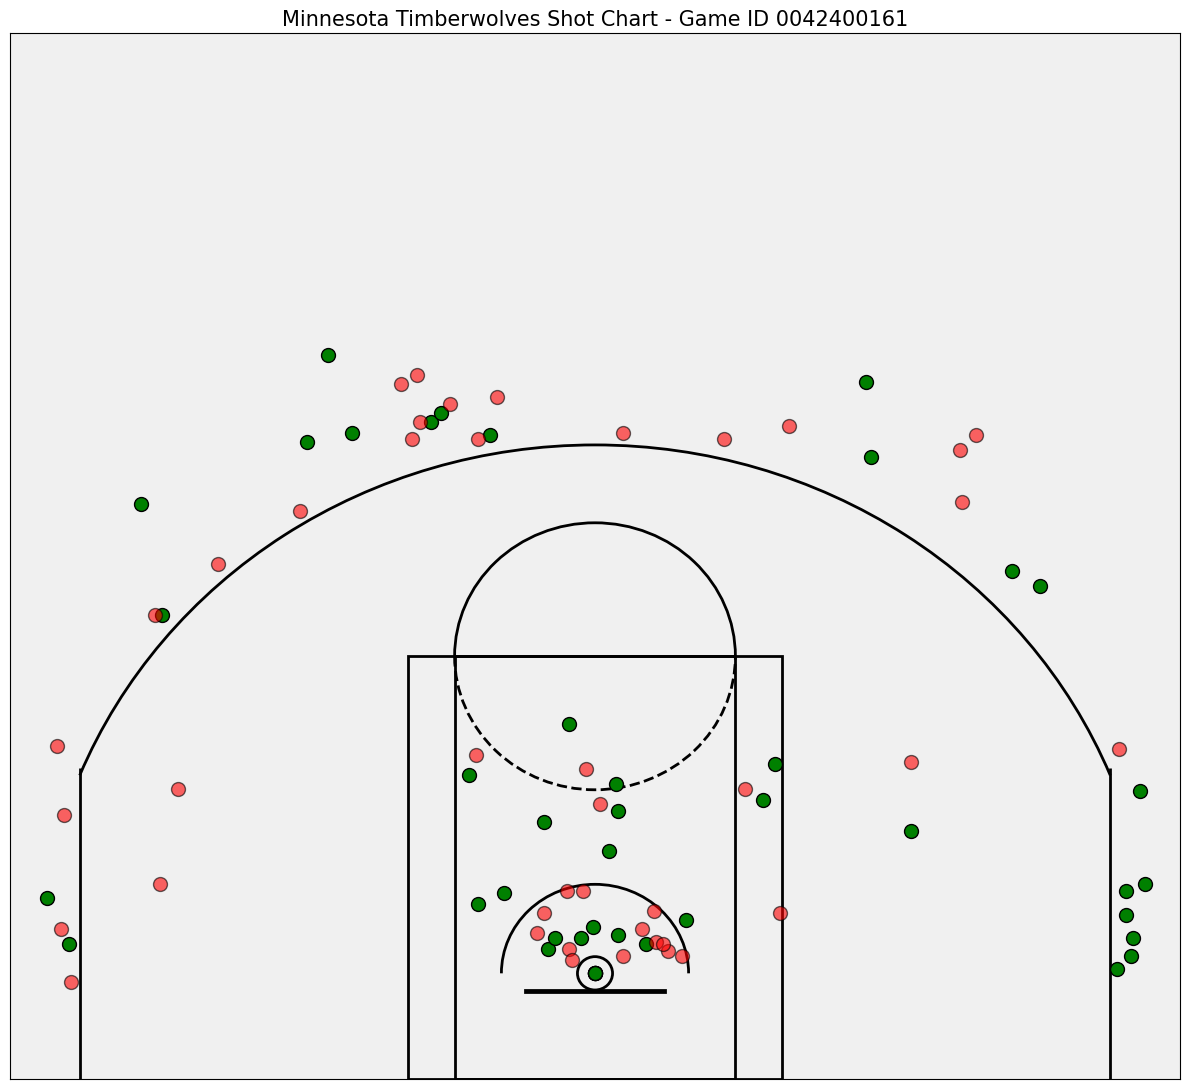

In [7]:
## Example: Plotting Minnesota Shots

min_shots = pd.read_csv('MIN_Shots_example.csv')
if not min_shots.empty:
    plot_team_shots(min_shots, 'Minnesota Timberwolves', '0042400161')
else:
    print("No shots found for that game.")